In [1]:
import requests


In [2]:
import pandas as pd

En este paso importamos requests para conectar con la API del Banco Central y pandas para manipular los datos financieros en formato de tabla.

conectar datos con banco central 

In [3]:
usuario = "d.poncepereira@outlook.com"
clave = "D1a2v3d4ox"

In [4]:
codigo_TPM_serie = "F022.TPM.TIN.D001.NO.Z.D"
fecha_inicio = "2016-01-01"
fecha_fin = "2026-07-01"

In [5]:
url = "https://si3.bcentral.cl/SieteRestWS/SieteRestWS.ashx"

# Armamos el diccionario con los parámetros que exige el Banco Central
parametros = {
    "user": usuario,
    "pass": clave,
    "firstdate": fecha_inicio,
    "lastdate": fecha_fin,
    "timeseries": codigo_TPM_serie,
    "function": "GetSeries"
}


In [6]:
# Hacemos la consulta y transformamos la respuesta a JSON
respuesta = requests.get(url, params=parametros)
datos = respuesta.json()

# Mostramos el resultado crudo
print(datos)

{'Codigo': 0, 'Descripcion': 'Success', 'Series': {'descripEsp': 'Tasa de política monetaria (TPM) (porcentaje)', 'descripIng': 'Monetary policy rate (MPR) (percentage)', 'seriesId': 'F022.TPM.TIN.D001.NO.Z.D', 'Obs': [{'indexDateString': '04-01-2016', 'value': '3.5', 'statusCode': 'OK'}, {'indexDateString': '05-01-2016', 'value': '3.5', 'statusCode': 'OK'}, {'indexDateString': '06-01-2016', 'value': '3.5', 'statusCode': 'OK'}, {'indexDateString': '07-01-2016', 'value': '3.5', 'statusCode': 'OK'}, {'indexDateString': '08-01-2016', 'value': '3.5', 'statusCode': 'OK'}, {'indexDateString': '09-01-2016', 'value': 'NaN', 'statusCode': 'ND'}, {'indexDateString': '10-01-2016', 'value': 'NaN', 'statusCode': 'ND'}, {'indexDateString': '11-01-2016', 'value': '3.5', 'statusCode': 'OK'}, {'indexDateString': '12-01-2016', 'value': '3.5', 'statusCode': 'OK'}, {'indexDateString': '13-01-2016', 'value': '3.5', 'statusCode': 'OK'}, {'indexDateString': '14-01-2016', 'value': '3.5', 'statusCode': 'OK'}, 

In [7]:
observaciones = datos["Series"]["Obs"]

In [8]:
df = pd.DataFrame(observaciones) #Convertir la lista en una tabla
df

,indexDateString,value,statusCode
0,04-01-2016,3.5,OK
1,05-01-2016,3.5,OK
2,06-01-2016,3.5,OK
3,07-01-2016,3.5,OK
4,08-01-2016,3.5,OK
...,...,...,...
3827,27-06-2026,NaN,ND
3828,28-06-2026,NaN,ND
3829,29-06-2026,NaN,ND
3830,30-06-2026,4.5,OK


In [9]:
df = pd.DataFrame(observaciones)

In [10]:
df = df[["indexDateString", "value"]]
df.columns = ["fecha", "valor"]

In [11]:
# Corregir los tipos de dato: convertir a fecha real y a número

df["fecha"] = pd.to_datetime(df["fecha"], format="%d-%m-%Y")
df["valor"] = pd.to_numeric(df["valor"], errors="coerce")

# Ordenar la tabla de la fecha más antigua a la más reciente
df = df.sort_values("fecha").reset_index(drop=True)

In [12]:
df.head() #Revisamos las primeras 5 filas de nuestra tabla limpia


,fecha,valor
0,2016-01-04,3.5
1,2016-01-05,3.5
2,2016-01-06,3.5
3,2016-01-07,3.5
4,2016-01-08,3.5


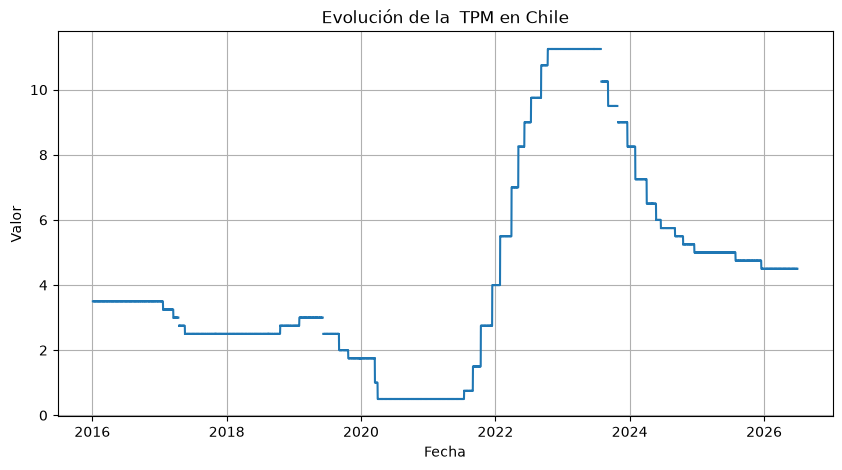

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(df["fecha"], df["valor"])
plt.title("Evolución de la  TPM en Chile")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.grid(True)
plt.show()

La forma de escalera que se observa, es el tipico comportamiento de las tasas de politica monetaria en la vida real. la explicacion de esta figura es por que los banco centrales toman decisiones en reuniones mensuales o bimensuales, la tasa se mantiene plana y luego salta de golpe.
La escalera de la TPM no es ruido; es el cronograma de ajuste del costo de la deuda. Para efectos prácticos, las mesetas son ventanas de certeza para fijar presupuestos y revisar el portafolio y no dormirse.

La regla de oro: Bono y tasa son como un sube y baja. Si la TPM sube (escalón arriba), el precio del bono que se compro baja. Si la TPM baja, el precio del bono que se tiene sube.



# Calcular el precio de un bono

El precio de un bono es la suma de los valores presentes de todos sus flujos de caja futuros (cupones periódicos más la devolución del principal al vencimiento), descontados a la tasa de interés requerida por el mercado (YTM).

In [14]:
def precio_bono(valor_nominal, tasa_cupon, tir, n_periodos, frecuencia=1):
    cupon= valor_nominal*tasa_cupon/frecuencia
    tir_periodo=tir/frecuencia
    n_total=n_periodos*frecuencia

    precio= 0
    for t in range(1,n_total+1):
        precio= precio+cupon/(1+tir_periodo)**t

    precio= precio+valor_nominal/(1+tir_periodo)**n_total
    return precio


    # SE CREA LA FUNCION DE COMO CALCULAR EL BONO

In [15]:
precio=precio_bono(valor_nominal=100, tasa_cupon=0.05, tir=0.06, n_periodos=5, frecuencia=2)

print(f"precio del bono: {precio:.4f}")

precio del bono: 95.7349


In [16]:
precio=precio_bono(valor_nominal=100, tasa_cupon=0.05, tir=0.04, n_periodos=5, frecuencia=2)

print(f"precio del bono: {precio:.4f}")

precio del bono: 104.4913


Esto confirma algo clave: cuando la tasa de mercado baja, el precio del bono sube — la relación inversa que antes se planteo.

# Medir el riesgo de tasa

Saber el precio de un bono hoy no es suficiente; necesitamos calcular un número que resuma qué tan sensible es el precio del bono a los cambios en la tasa de interés. La Duración de Macaulay responde a la pregunta de cuánto tiempo promedio se debe esperar para recibir el valor de este bono. Mientras más largo sea ese tiempo promedio, más sensible es el precio a los cambios de tasa.

NOTA: La Duración de Macaulay es el plazo medio ponderado que tarda un inversor en recuperar los flujos de efectivo de un bono, medido en años. Desarrollada por Frederick Macaulay en 1938, funciona como una métrica del vencimiento efectivo de un instrumento financiero y sirve como base para medir el riesgo de tasa de interés

In [17]:
def duracion_macaulay(valor_nominal, tasa_cupon, tir, n_periodos, frecuencia=1):
    cupon = valor_nominal * tasa_cupon / frecuencia
    tir_periodo = tir / frecuencia
    n_total = n_periodos * frecuencia
    
    precio = precio_bono(valor_nominal, tasa_cupon, tir, n_periodos, frecuencia)
    
    duracion_ponderada = 0
    for t in range(1, n_total + 1):
        flujo = cupon
        if t == n_total:
            flujo = flujo + valor_nominal
            
        valor_presente_flujo = flujo / (1 + tir_periodo) ** t
        duracion_ponderada = duracion_ponderada + t * valor_presente_flujo
        
    duracion_periodos = duracion_ponderada / precio
    duracion_anual = duracion_periodos / frecuencia
    
    return duracion_anual

# SE CREA LA FUNCION DE COMO CALCULAR LA DURACION DE MACAULAY

# Planteamiento del Problema: Medición del Riesgo de Tasa

*Contexto de Mercado:*
Saber el precio de un bono hoy no es suficiente. Como evidenciamos en el gráfico de evolución de la TPM, el costo del dinero cambia constantemente debido a las decisiones de política monetaria.

*El Objetivo:*
Calcular una métrica matemática que responda a la pregunta: ¿cuánto tiempo, en promedio, tengo que esperar para recibir el valor de este bono?. Esta métrica debe servir como un indicador directo de la sensibilidad del precio ante futuros shocks en las tasas de interés.

In [18]:
duracion = duracion_macaulay(valor_nominal=100, tasa_cupon=0.05, tir=0.06, n_periodos=5, frecuencia=2)
print(f"Duración de Macaulay: {duracion:.1f} años")

Duración de Macaulay: 4.5 años


Aunque el bono tiene un plazo legal de 5 años, la duración es menor (4.47 años) porque no se tiene que esperar hasta el final para recibir todo el dinero; recibes flujos de caja periódicos (los cupones semestrales) antes del vencimiento final.
Este número de 4.47 resume qué tan sensible es el precio del bono a los cambios en la tasa de interés. Responde exactamente a la pregunta de cuánto tiempo, en promedio, se tiene que esperar para recibir el valor de este bono.
Por lo tanto mientras mas largo sea ese tiempo promedio(una duracion mas alta), mas violento sera el impacto en el precio si la tasa sube o baja

# Análisis de Escenarios (Stress Testing) y Convexidad

*Contexto de Mercado:*
Entender la Duración de Macaulay nos da un promedio de sensibilidad, pero el mercado no se mueve en promedios estáticos. Antes de tomar una posición real, es obligatorio estresar el instrumento ante distintos escenarios de tasa, para entender el riesgo antes de que el movimiento ocurra de verdad.

*El Desafío Analítico:*
Necesitamos visualizar la relación completa entre el precio y la tasa para este bono. A diferencia de otros activos financieros que tienen un comportamiento lineal, los bonos presentan una curvatura natural en su valoración.

*El Objetivo:*
Generar un gráfico que muestre el precio del bono para muchas tasas de mercado distintas, simulando shocks tanto alcistas como bajistas. Esto nos permitirá observar gráficamente la "convexidad" del instrumento.

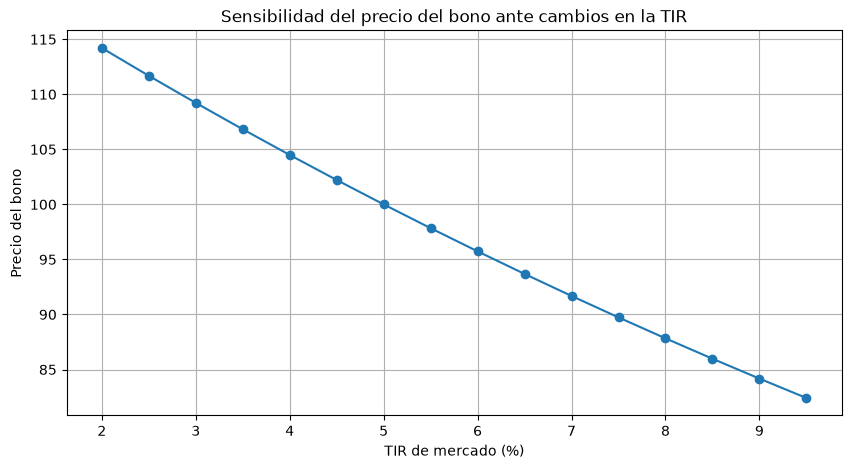

In [19]:
import numpy as np

# 1. Generamos los escenarios: tasas hipotéticas desde el 2% hasta el 10%, avanzando de a 0.5%
tasas_shock = np.arange(0.02, 0.10, 0.005)
precios_shock = []

# 2. Simulamos el impacto: calculamos el precio del bono para cada tasa posible
for t in tasas_shock:
    precio_en_ese_escenario = precio_bono(100, 0.05, t, 5, frecuencia=2)
    precios_shock.append(precio_en_ese_escenario)

# 3. Graficamos la curva de sensibilidad (Convexidad)
plt.figure(figsize=(10, 5))
plt.plot(tasas_shock * 100, precios_shock, marker="o")
plt.title("Sensibilidad del precio del bono ante cambios en la TIR")
plt.xlabel("TIR de mercado (%)")
plt.ylabel("Precio del bono")
plt.grid(True)
plt.show()

*vamos a asumir un escenario muy realista*: vamos a simular que el rendimiento de tu bono de mercado (la TIR) se mueve en paralelo a la TPM, sumándole un spread fijo (por ejemplo, 1.5%).

In [20]:
# 1. Definimos un spread técnico (ej: 1.5% por encima de la TPM)
spread = 0.015

# 2. Creamos una columna con la TIR estimada diaria. 
# Como la TPM de la tabla está en número entero (ej: 4.5), la dividimos por 100.

df["TIR_estimada"] = (df["valor"] / 100) + spread

# 3. Cruzamos la tabla con tu función de precio usando 'apply' y 'lambda'
# Esto le dice a Python: "Por cada TIR de la tabla, calcula el precio del bono a 5 años"

df["precio_historico_bono"] = df["TIR_estimada"].apply(
    lambda tir_diaria: precio_bono(valor_nominal=100, tasa_cupon=0.05, tir=tir_diaria, n_periodos=5, frecuencia=2)
)

# 4. Revisamos las primeras filas de la tabla ya cruzada
df.tail()

,fecha,valor,TIR_estimada,precio_historico_bono
3827,2026-06-27,NaN,NaN,NaN
3828,2026-06-28,NaN,NaN,NaN
3829,2026-06-29,NaN,NaN,NaN
3830,2026-06-30,4.5,0.06,95.734899
3831,2026-07-01,4.5,0.06,95.734899


In [21]:
df


,fecha,valor,TIR_estimada,precio_historico_bono
0,2016-01-04,3.5,0.05,100.000000
1,2016-01-05,3.5,0.05,100.000000
2,2016-01-06,3.5,0.05,100.000000
3,2016-01-07,3.5,0.05,100.000000
4,2016-01-08,3.5,0.05,100.000000
...,...,...,...,...
3827,2026-06-27,NaN,NaN,NaN
3828,2026-06-28,NaN,NaN,NaN
3829,2026-06-29,NaN,NaN,NaN
3830,2026-06-30,4.5,0.06,95.734899


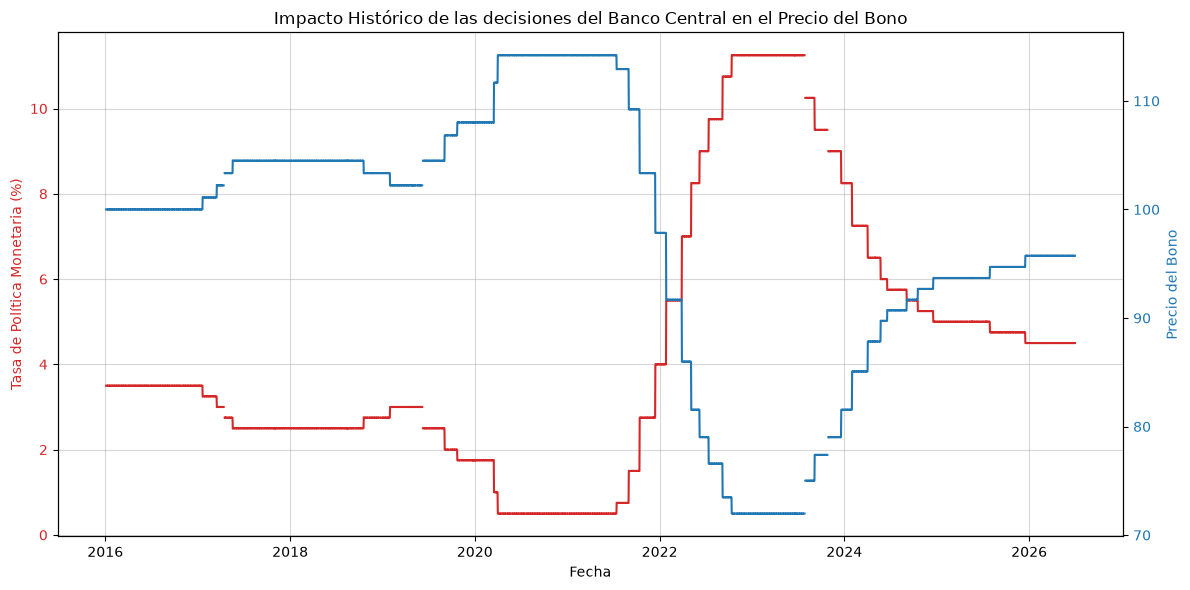

In [22]:
import matplotlib.pyplot as plt

# 1. Configuramos el tamaño del lienzo
fig, eje_izq = plt.subplots(figsize=(12, 6))

# 2. Configuramos el Eje Izquierdo (Para la TPM)
color_tasa = 'tab:red'
eje_izq.set_xlabel('Fecha')
eje_izq.set_ylabel('Tasa de Política Monetaria (%)', color=color_tasa)
eje_izq.plot(df['fecha'], df['valor'], color=color_tasa, linewidth=1.5)
eje_izq.tick_params(axis='y', labelcolor=color_tasa)

# 3. Creamos un Eje Derecho que comparte las mismas fechas (Eje X)
eje_der = eje_izq.twinx()  

# 4. Configuramos el Eje Derecho (Para el Precio del Bono)
color_precio = 'tab:blue'
eje_der.set_ylabel('Precio del Bono', color=color_precio)
eje_der.plot(df['fecha'], df['precio_historico_bono'], color=color_precio, linewidth=1.5)
eje_der.tick_params(axis='y', labelcolor=color_precio)

# 5. Detalles finales de formato
plt.title('Impacto Histórico de las decisiones del Banco Central en el Precio del Bono')
eje_izq.grid(True, alpha=0.5)
fig.tight_layout() # Ajusta los márgenes automáticamente
plt.show()

el resultado es la demostración visual definitiva de la regla de oro de la renta fija.
Captura a la perfección la simetría inversa.

*El ciclo de endurecimiento (2021 - 2023)*: Cuando el Banco Central subió agresivamente la tasa desde el 0.5% hasta más del 11% (línea roja), el portafolio sufrió una caída brutal, pasando de un precio de ~115 a cerca de 70 (línea azul). Quien no midió su Duración de Macaulay aquí, asumió pérdidas de capital altísimas.

*El ciclo de recortes (2024 en adelante)*: Al iniciar las bajadas de tasa, el precio del bono comenzó su rally de recuperación. Aquí es donde los analistas toman posiciones largas en bonos para capturar ganancias de capital.

#  El Espejo de la Renta Fija

La simetría inversa expuesta en este gráfico confirma visual y matemáticamente la regla fundamental de la renta fija: **el precio y la tasa se mueven en direcciones opuestas**.

*Ciclos de Restricción:* Cuando el Banco Central endurece la política monetaria subiendo la TPM (como se observa en el violento salto de 2021-2023), el valor de los bonos en cartera se desploma.
*Ciclos de Expansión:* Cuando inician los recortes de tasa, los precios de los bonos experimentan un rally de recuperación, generando oportunidades para capturar ganancias de capital.

Al fusionar la extracción automatizada de datos macroeconómicos con algoritmos propios de valorización (`precio_bono` y `duracion_macaulay`), se construye un motor analítico capaz de estresar posiciones y medir el riesgo de mercado antes de que ocurran los movimientos, replicando el estándar operativo de una mesa de dinero institucional.

# problema simulado

*El Contexto (Nuevos Datos Macroeconómicos)*
Son las 08:30 AM del martes. El mercado operaba bajo el consenso de que el Banco Central mantendría la TPM en 4.50%. Sin embargo, el Instituto Nacional de Estadísticas (INE) acaba de publicar el dato de inflación (IPC) del mes, arrojando una sorpresa brutal del +0.8% (cuando se esperaba solo un +0.2%).

Los forwards de tasas se disparan instantáneamente. La mesa de dinero ahora proyecta que el Banco Central se verá obligado a aplicar un "shock" defensivo y subirá la tasa al 5.25% (+75 puntos base) en su reunión de mañana para anclar las expectativas y frenar la inflación.

*La Posición en la Mesa (Libro de Trading)*
Eres el analista cuantitativo a cargo del libro de renta fija en moneda local. Tu portafolio actual tiene la siguiente posición estructural:

**Activo**: Bono de Tesorería (BTP) a 10 años.

**Valor Nominal (Exposición)**: 10.000 millones de pesos (CLP).

**Tasa Cupón**: 4.5% (pagadero semestral).

**TIR Actual (Cierre de ayer)**: 4.5% (El bono cerró cotizando exactamente a par, precio = 100).


los mercados abren en 30 minutos

*¿Cuánto dinero exacto va a perder (o ganar) nuestro portafolio hoy en la apertura del mercado debido a este nuevo choque macroeconómico?*

In [23]:
duracion= duracion_macaulay(valor_nominal=100,tasa_cupon=0.045, tir=0.045, n_periodos=10, frecuencia=2)

print(f"Duración de Macaulay: {duracion:.1f} años")


Duración de Macaulay: 8.2 años


Por cada 1% (100 puntos base) que suba la curva de rendimiento, el portafolio perderá aproximadamente un 8.15% de su valor.

*el shock proyectado es de + 75 puntos Base*
-8.15 * 0.75% = -6.11%.

Sobre una posición de 10.000 millones, la pérdida de capital latente es de 611 millones de pesos en la apertura si no se toma acción inmediata.

In [24]:
precio= precio_bono(valor_nominal=100,tasa_cupon=0.045, tir=0.0525,n_periodos=10, frecuencia=2)

print(f"precio del bono: {precio:.2f}")



precio del bono: 94.22


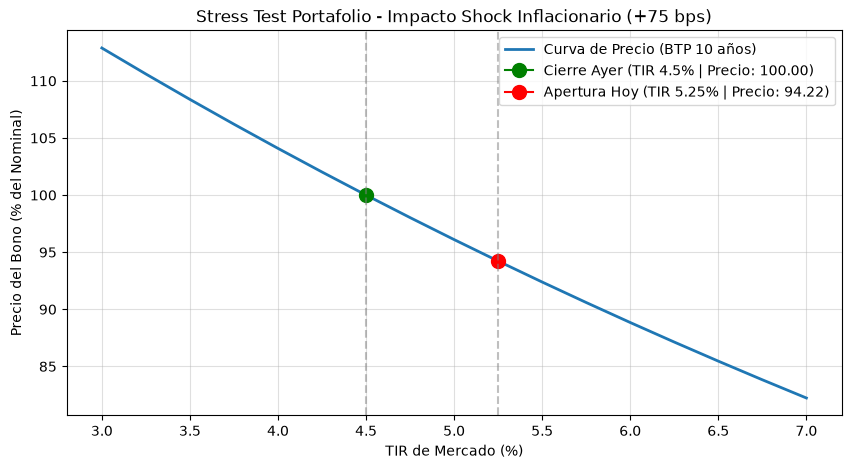

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definimos el rango de tasas para este escenario específico (ej: desde 3% hasta 7%)
tasas_shock_caso = np.arange(0.03, 0.07, 0.0025)
precios_shock_caso = []

# 2. Simulamos el impacto para tu portafolio: BTP a 10 años, cupón 4.5%
for t in tasas_shock_caso:
    # Usamos n_periodos=10 y tasa_cupon=0.045
    precio = precio_bono(valor_nominal=100, tasa_cupon=0.045, tir=t, n_periodos=10, frecuencia=2)
    precios_shock_caso.append(precio)

# 3. Calculamos los dos puntos críticos del caso de estudio
precio_ayer = precio_bono(100, 0.045, 0.045, 10, frecuencia=2)  # Escenario base
precio_hoy = precio_bono(100, 0.045, 0.0525, 10, frecuencia=2)  # Escenario shock

# 4. Graficamos el Stress Test
plt.figure(figsize=(10, 5))
plt.plot(tasas_shock_caso * 100, precios_shock_caso, color='tab:blue', linewidth=2, label="Curva de Precio (BTP 10 años)")

# Marcamos el cierre de ayer (Punto Verde)
plt.plot(4.5, precio_ayer, marker="o", markersize=10, color="green", 
         label=f"Cierre Ayer (TIR 4.5% | Precio: {precio_ayer:.2f})")

# Marcamos el impacto del IPC hoy (Punto Rojo)
plt.plot(5.25, precio_hoy, marker="o", markersize=10, color="red", 
         label=f"Apertura Hoy (TIR 5.25% | Precio: {precio_hoy:.2f})")

# Detalles de diseño para el reporte
plt.title("Stress Test Portafolio - Impacto Shock Inflacionario (+75 bps)")
plt.xlabel("TIR de Mercado (%)")
plt.ylabel("Precio del Bono (% del Nominal)")
plt.axvline(x=4.5, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=5.25, color='gray', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()